# Backpropagation from scratch

Meridian Instruments tests every optical sensor it builds on two calibration
axes, and accepts a unit when both offsets are jointly small enough for the
firmware's global correction to absorb them. That word *jointly* is the whole
problem: the accept region is the inside of a closed curve, and no straight
line encloses anything.

This notebook builds a one-hidden-layer network with nothing but NumPy —
forward pass, loss, and the backward pass derived in handout section 5 — and
checks the gradient against finite differences before trusting it. Then it
asks what a hidden layer actually buys, by counting lines.

Handout sections 2 to 6.

## 1. Setup

In [1]:
# pip install numpy==1.26.4 pandas==2.1.1 matplotlib==3.8.0 scikit-learn==1.3.1 scipy==1.11.3

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import integrate

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from instrument_data import (make_acceptance_test, make_channel_drift,
                             TRUE_ACCEPT_RADIUS_SIGMA, TRUE_RIG_ERROR_RATE)

FIGURES = Path.cwd().parent / "Figures"
FIGURES.mkdir(exist_ok=True)

BLUE, TEAL, RUST, GOLD, PLUM = "#1F4E79", "#2E8B8B", "#B4483E", "#C9A227", "#7B4B94"

RNG_SEED = 42
np.random.seed(RNG_SEED)

units = make_acceptance_test()
print(f"{len(units)} sensors, 2 measurements each")
print(f"recorded as accepted  : {units.accepted.mean():.4f}")
print(f"truly within tolerance: {units.truly_within_tolerance.mean():.4f}")
print(f"verdicts the rig got wrong: "
      f"{(units.accepted != units.truly_within_tolerance).mean():.4f} "
      f"(designed: {TRUE_RIG_ERROR_RATE})")
units.head()

3000 sensors, 2 measurements each
recorded as accepted  : 0.5473
truly within tolerance: 0.5497
verdicts the rig got wrong: 0.0330 (designed: 0.03)


,gain_offset_db,phase_offset_deg,accepted,truly_within_tolerance
0,0.007391,-2.785732,1,1
1,-0.476210,0.583827,1,1
2,-0.224146,1.230738,1,1
3,0.916919,-2.033485,0,0
4,-0.188504,-3.942666,0,0


## 2. Split first, then look

The split comes before the scaling, and the scaler is fitted on the training
half alone. That is lesson 2's rule and it has not been repealed: a
`StandardScaler` fitted on everything would carry the test set's mean and
spread into training.

Both measurements are standardised because they are on wildly different
scales — decibels against degrees — and a network's first layer computes
weighted sums. An input ranging over tens forces its weight to be tiny, and
gradient descent then has to move weights of very different magnitudes with a
single learning rate. Lesson 3 made this point about the condition number of
the design matrix; here it is the difference between training working and not.

In [2]:
X = units[["gain_offset_db", "phase_offset_deg"]].values
y = units["accepted"].values
truth = units["truly_within_tolerance"].values

X_tr, X_te, y_tr, y_te, t_tr, t_te = train_test_split(
    X, y, truth, test_size=0.25, stratify=y, random_state=9101)

scaler = StandardScaler().fit(X_tr)          # fitted on training data only
Z_tr, Z_te = scaler.transform(X_tr), scaler.transform(X_te)

print(f"train {X_tr.shape}   test {X_te.shape}")
print(f"scaler means  {scaler.mean_.round(4)}")
print(f"scaler scales {scaler.scale_.round(4)}")
print("the true production spreads are 0.40 dB and 3.00 degrees")

train (2250, 2)   test (750, 2)
scaler means  [ 0.0068 -0.0307]
scaler scales [0.3903 3.0573]
the true production spreads are 0.40 dB and 3.00 degrees


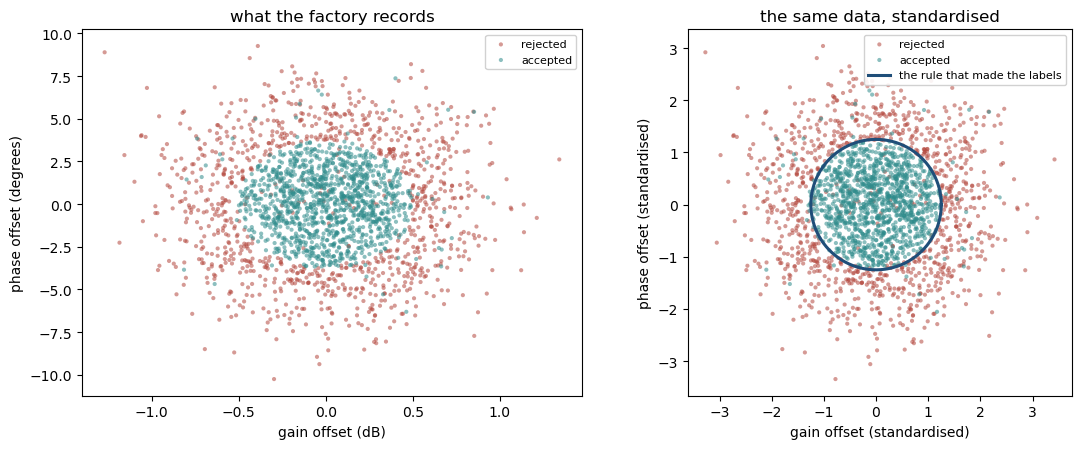

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))

ax = axes[0]
for label, colour, name in ((0, RUST, "rejected"), (1, TEAL, "accepted")):
    m = y_tr == label
    ax.scatter(X_tr[m, 0], X_tr[m, 1], s=9, c=colour, alpha=.55,
               edgecolor="none", label=name)
ax.set_xlabel("gain offset (dB)")
ax.set_ylabel("phase offset (degrees)")
ax.set_title("what the factory records")
ax.legend(loc="upper right", fontsize=8, framealpha=.9)

ax = axes[1]
for label, colour, name in ((0, RUST, "rejected"), (1, TEAL, "accepted")):
    m = y_tr == label
    ax.scatter(Z_tr[m, 0], Z_tr[m, 1], s=9, c=colour, alpha=.55,
               edgecolor="none", label=name)
theta = np.linspace(0, 2 * np.pi, 400)
ax.plot(TRUE_ACCEPT_RADIUS_SIGMA * np.cos(theta),
        TRUE_ACCEPT_RADIUS_SIGMA * np.sin(theta),
        color=BLUE, lw=2.2, label="the rule that made the labels")
ax.set_xlabel("gain offset (standardised)")
ax.set_ylabel("phase offset (standardised)")
ax.set_title("the same data, standardised")
ax.legend(loc="upper right", fontsize=8, framealpha=.9)
ax.set_aspect("equal")

fig.tight_layout()
fig.savefig(FIGURES / "acceptance_data.png", dpi=150)
plt.show()

The right-hand panel draws something Meridian's engineers never see. Both
tolerances are the same multiple of their axis's production spread — 0.50 dB
against a spread of 0.40, 3.75 degrees against 3.00 — so once each axis is
divided by its own spread the accept region is a **circle of radius 1.25**.
The scattered points of the wrong colour along that circle are the test rig's
3% error rate.

That 3% is a hard ceiling. A classifier reproducing the true rule *exactly*
would still disagree with 3% of the recorded verdicts, so **0.97 is the best
test accuracy anything in this notebook can reach**, and every score below
should be read against 0.97 rather than against 1.

## 3. What one straight line can do

Logistic regression from lesson 4 is exactly one neuron: a weighted sum of the
inputs, squashed by a sigmoid. Its decision boundary is the set of points
where the weighted sum is zero — a straight line. Fit it and see.

In [4]:
linear = LogisticRegression().fit(Z_tr, y_tr)
linear_acc = linear.score(Z_te, y_te)
majority = max(y_te.mean(), 1 - y_te.mean())

print(f"logistic regression, test accuracy: {linear_acc:.4f}")
print(f"  coefficients {linear.coef_.round(4)}  intercept {linear.intercept_.round(4)}")
print(f"  predict 'accepted' always        : {majority:.4f}")
print(f"  the rig's ceiling                : {1 - TRUE_RIG_ERROR_RATE:.4f}")

logistic regression, test accuracy: 0.5507
  coefficients [[0.0096 0.0701]]  intercept [0.1892]
  predict 'accepted' always        : 0.5480
  the rig's ceiling                : 0.9700


The coefficients are almost zero and the accuracy is almost exactly the
majority-class rate. That is not a failure of the optimiser — it is the right
answer to the wrong question. The accept region is a disc centred on the
origin, so it is symmetric: for every accepted unit at $(z_1, z_2)$ there is a
matching one at $(-z_1, -z_2)$. Any line that gains on one side loses the same
amount on the other, and the fit settles for tilting almost not at all.

It is worth knowing how much a line could manage if it tried. Brute-force it
over every direction and every offset.

In [5]:
def best_half_plane(Z, labels, n_angles=181, n_offsets=201):
    """Best accuracy of any single straight boundary, by brute force."""
    best = (0.0, None, None, None)
    for angle in np.linspace(0, np.pi, n_angles):
        w = np.array([np.cos(angle), np.sin(angle)])
        projection = Z @ w
        for threshold in np.quantile(projection, np.linspace(0, 1, n_offsets)):
            for sign in (1, -1):
                acc = (((projection - threshold) * sign > 0).astype(int)
                       == labels).mean()
                if acc > best[0]:
                    best = (acc, w, threshold, sign)
    return best


line_acc, line_w, line_t, line_sign = best_half_plane(Z_te, y_te)
print(f"the best straight line anywhere on this test set: {line_acc:.4f}")
print(f"  fitted logistic regression got                : {linear_acc:.4f}")
print("  the best line works by cutting off one far tail, where almost")
print("  every unit is a reject — it does not enclose the accept region")
print("\n  note: this search picks the winner ON the test set, out of")
print("  72,762 candidate lines, so it is optimistic. Section 9 computes")
print("  the best line for the population, which is lower.")

the best straight line anywhere on this test set: 0.6880
  fitted logistic regression got                : 0.5507
  the best line works by cutting off one far tail, where almost
  every unit is a reject — it does not enclose the accept region

  note: this search picks the winner ON the test set, out of
  72,762 candidate lines, so it is optimistic. Section 9 computes
  the best line for the population, which is lower.


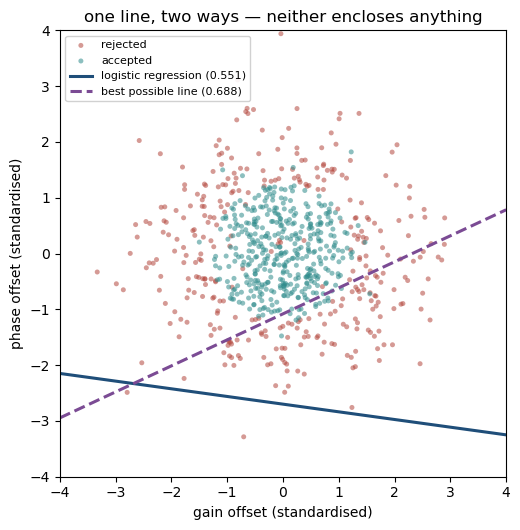

In [6]:
fig, ax = plt.subplots(figsize=(6.4, 5.4))
for label, colour, name in ((0, RUST, "rejected"), (1, TEAL, "accepted")):
    m = y_te == label
    ax.scatter(Z_te[m, 0], Z_te[m, 1], s=13, c=colour, alpha=.55,
               edgecolor="none", label=name)

grid = np.linspace(-4, 4, 300)
xx, yy = np.meshgrid(grid, grid)
flat = np.c_[xx.ravel(), yy.ravel()]
ax.contour(xx, yy, linear.predict_proba(flat)[:, 1].reshape(xx.shape),
           levels=[0.5], colors=[BLUE], linewidths=2.2)
ax.contour(xx, yy, ((flat @ line_w - line_t) * line_sign).reshape(xx.shape),
           levels=[0.0], colors=[PLUM], linewidths=2.2, linestyles="--")

ax.plot([], [], color=BLUE, lw=2.2, label=f"logistic regression ({linear_acc:.3f})")
ax.plot([], [], color=PLUM, lw=2.2, ls="--", label=f"best possible line ({line_acc:.3f})")
ax.set_xlabel("gain offset (standardised)")
ax.set_ylabel("phase offset (standardised)")
ax.set_title("one line, two ways — neither encloses anything")
ax.legend(loc="upper left", fontsize=8, framealpha=.9)
ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
ax.set_aspect("equal")
fig.tight_layout()
fig.savefig(FIGURES / "linear_boundary_fails.png", dpi=150)
plt.show()

## 4. The forward pass

One hidden layer of $H$ units, then one output unit:

$$Z^{[1]} = X W^{[1]} + b^{[1]}, \quad A^{[1]} = \mathrm{ReLU}(Z^{[1]}),
\quad Z^{[2]} = A^{[1]} W^{[2]} + b^{[2]}, \quad \hat{y} = \sigma(Z^{[2]})$$

The shapes are the thing to hold onto, because almost every bug in a network
written by hand is a shape bug. With $m$ examples, $n$ inputs and $H$ hidden
units: $X$ is $m \times n$, $W^{[1]}$ is $n \times H$, $A^{[1]}$ is
$m \times H$, $W^{[2]}$ is $H \times 1$, and $\hat{y}$ is $m \times 1$.

Every example flows through independently — the row index never mixes.

In [7]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))


def initialise(n_inputs, n_hidden, rng):
    """He initialisation: variance 2/fan_in, derived in handout section 8.2."""
    return [rng.normal(0, np.sqrt(2.0 / n_inputs), (n_inputs, n_hidden)),
            np.zeros(n_hidden),
            rng.normal(0, np.sqrt(2.0 / n_hidden), (n_hidden, 1)),
            np.zeros(1)]


def forward(params, X):
    W1, b1, W2, b2 = params
    Z1 = X @ W1 + b1
    A1 = np.maximum(0.0, Z1)
    Z2 = A1 @ W2 + b2
    return Z1, A1, sigmoid(Z2)


def cost(params, X, y):
    """Binary cross-entropy, averaged over the batch."""
    p = np.clip(forward(params, X)[2].ravel(), 1e-12, 1 - 1e-12)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))


rng = np.random.default_rng(0)
demo = initialise(2, 4, rng)
Z1, A1, yhat = forward(demo, Z_tr)
print(f"X {Z_tr.shape}   W1 {demo[0].shape}   Z1 {Z1.shape}   "
      f"A1 {A1.shape}   W2 {demo[2].shape}   yhat {yhat.shape}")
print(f"cost of an untrained network: {cost(demo, Z_tr, y_tr):.4f}")
print(f"cost of guessing (log 2)    : {np.log(2):.4f}")

X (2250, 2)   W1 (2, 4)   Z1 (2250, 4)   A1 (2250, 4)   W2 (4, 1)   yhat (2250, 1)
cost of an untrained network: 0.6721
cost of guessing (log 2)    : 0.6931


## 5. The backward pass

Handout section 5 derives this. The result, in the same shapes:

$$\frac{\partial J}{\partial Z^{[2]}} = \frac{1}{m}(\hat{y} - y), \qquad
\frac{\partial J}{\partial W^{[2]}} = (A^{[1]})^{\top} \frac{\partial J}{\partial Z^{[2]}}$$

$$\frac{\partial J}{\partial Z^{[1]}} = \left(\frac{\partial J}{\partial Z^{[2]}} (W^{[2]})^{\top}\right) \odot \mathbb{1}[Z^{[1]} > 0], \qquad
\frac{\partial J}{\partial W^{[1]}} = X^{\top} \frac{\partial J}{\partial Z^{[1]}}$$

Two things are worth reading off rather than memorising. The sigmoid and the
cross-entropy collapse into $\hat{y} - y$ — the derivative of the squashing
function cancels against the derivative of the loss, which is *why* this pair
is used together. And the ReLU's derivative is an indicator: a unit whose
pre-activation was negative passes nothing back, because it contributed
nothing forward.

Each gradient has the shape of the thing it is a gradient of, and the
assertions below say so out loud.

In [8]:
def backward(params, X, y):
    W1, b1, W2, b2 = params
    m = X.shape[0]
    Z1, A1, yhat = forward(params, X)

    dZ2 = (yhat - y.reshape(-1, 1)) / m            # (m, 1)
    dW2 = A1.T @ dZ2                               # (H, 1)
    db2 = dZ2.sum(axis=0)                          # (1,)

    dA1 = dZ2 @ W2.T                               # (m, H)
    dZ1 = dA1 * (Z1 > 0)                           # (m, H)  ReLU derivative
    dW1 = X.T @ dZ1                                # (n, H)
    db1 = dZ1.sum(axis=0)                          # (H,)

    assert dW1.shape == W1.shape and db1.shape == b1.shape
    assert dW2.shape == W2.shape and db2.shape == b2.shape
    return [dW1, db1, dW2, db2]


for name, g in zip(("dW1", "db1", "dW2", "db2"), backward(demo, Z_tr, y_tr)):
    print(f"{name}: shape {str(g.shape):8s} norm {np.linalg.norm(g):.6f}")

dW1: shape (2, 4)   norm 0.046239
db1: shape (4,)     norm 0.115557
dW2: shape (4, 1)   norm 0.069418
db2: shape (1,)     norm 0.160375


## 6. Check the gradient before trusting it

An analytic gradient that is wrong will still train — badly, and silently.
The defence is four lines: perturb one parameter by a tiny $h$ in each
direction and compare the slope of the cost against what the formula claims.

$$\frac{\partial J}{\partial \theta_i} \approx \frac{J(\theta + h e_i) - J(\theta - h e_i)}{2h}$$

The two-sided difference has error $O(h^2)$ rather than $O(h)$, which is why
it is used instead of the one-sided version. In double precision with
$h = 10^{-5}$, a correct gradient agrees to something like $10^{-8}$ relative
or better; anything above $10^{-4}$ is a bug, not rounding.

In [9]:
def gradient_check(params, X, y, h=1e-5):
    """Compare every analytic partial derivative against a finite difference."""
    analytic = backward(params, X, y)
    pairs = []
    for tensor, grad in zip(params, analytic):
        flat, flat_grad = tensor.ravel(), grad.ravel()
        for i in range(flat.size):
            original = flat[i]
            flat[i] = original + h
            up = cost(params, X, y)
            flat[i] = original - h
            down = cost(params, X, y)
            flat[i] = original
            pairs.append(((up - down) / (2 * h), flat_grad[i]))
    return np.array(pairs)


check = gradient_check(initialise(2, 5, np.random.default_rng(7)),
                       Z_tr[:64], y_tr[:64])
numerical, analytic = check[:, 0], check[:, 1]
relative = np.abs(numerical - analytic) / np.maximum(
    1e-12, np.abs(numerical) + np.abs(analytic))

print(f"{len(check)} partial derivatives checked")
print(f"worst relative disagreement : {relative.max():.3e}")
print(f"median relative disagreement: {np.median(relative):.3e}")
print("verdict:", "PASS" if relative.max() < 1e-6 else "FAIL — the gradient is wrong")

21 partial derivatives checked
worst relative disagreement : 1.972e-08
median relative disagreement: 7.832e-11
verdict: PASS


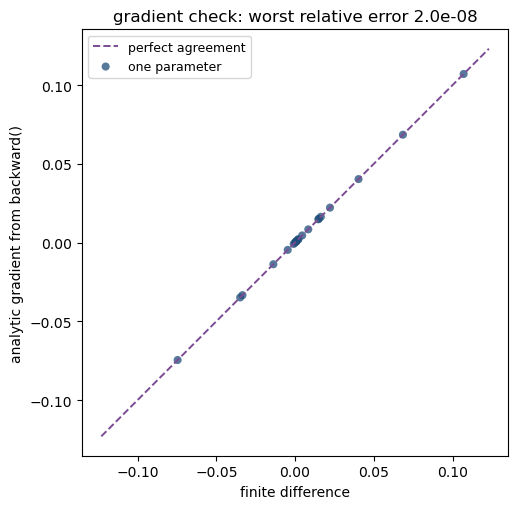

In [10]:
fig, ax = plt.subplots(figsize=(5.6, 5.2))
limit = np.abs(np.r_[numerical, analytic]).max() * 1.15
ax.plot([-limit, limit], [-limit, limit], color=PLUM, lw=1.4, ls="--",
        label="perfect agreement")
ax.scatter(numerical, analytic, s=34, c=BLUE, alpha=.75, edgecolor="none",
           label="one parameter")
ax.set_xlabel("finite difference")
ax.set_ylabel("analytic gradient from backward()")
ax.set_title(f"gradient check: worst relative error {relative.max():.1e}")
ax.legend(loc="upper left", fontsize=9)
ax.set_aspect("equal")
fig.tight_layout()
fig.savefig(FIGURES / "gradient_check.png", dpi=150)
plt.show()

## 7. Training, and what four hidden units do

Mini-batch gradient descent: lesson 3's update rule, applied to four parameter
arrays instead of one vector.

One addition, and it is not decoration. The cost here is **not convex** — the
same architecture from two different starting points lands in two different
places — so a single run is a sample, not an answer. The fix is the one
lesson 8 used for k-means: run it several times and keep the best. "Best"
means lowest **training** cost. The test set takes no part in the choice, or
the score it later reports would be worthless.

In [11]:
def train(X, y, n_hidden, epochs=400, learning_rate=0.3, batch_size=64,
          seed=0, params=None):
    rng = np.random.default_rng(seed)
    if params is None:
        params = initialise(X.shape[1], n_hidden, rng)
    m = X.shape[0]
    history = []
    for epoch in range(epochs):
        order = rng.permutation(m)
        for start in range(0, m, batch_size):
            batch = order[start:start + batch_size]
            for tensor, grad in zip(params, backward(params, X[batch], y[batch])):
                tensor -= learning_rate * grad
        history.append(cost(params, X, y))
    return params, np.array(history)


def accuracy(params, X, y):
    return ((forward(params, X)[2].ravel() > 0.5).astype(int) == y).mean()


def train_restarts(X, y, n_hidden, restarts=5, seed=0, **kwargs):
    """Fit from several starts, keep the one with the lowest TRAINING cost."""
    runs = [train(X, y, n_hidden, seed=seed + r, **kwargs)
            for r in range(restarts)]
    costs = [run[1][-1] for run in runs]
    print(f"  {restarts} restarts, final training cost: "
          f"{', '.join(f'{c:.4f}' for c in sorted(costs))}")
    return min(runs, key=lambda run: run[1][-1])


rows = []
for rate in (0.05, 0.1, 0.3, 0.5, 1.0):
    finals, rising = [], 0
    for s in range(8):
        _, history = train(Z_tr, y_tr, 4, learning_rate=rate, seed=100 + s)
        finals.append(history[-1])
        rising += history[-1] > history.min() + 0.01
    rows.append({"learning rate": rate,
                 "mean final cost": round(float(np.mean(finals)), 4),
                 "runs ending above their own minimum": f"{rising}/8"})
print("the same 4-unit network at five learning rates, 400 epochs each\n")
pd.DataFrame(rows).set_index("learning rate")

the same 4-unit network at five learning rates, 400 epochs each



,mean final cost,runs ending above their own minimum
learning rate,,
0.05,0.2596,1/8
0.10,0.2638,1/8
0.30,0.3088,3/8
0.50,0.3640,5/8
1.00,0.3094,6/8


The last column is the one to read. At a learning rate of 0.5 most runs end
**above** the lowest cost they themselves reached: the network finds a good
solution part way through and then leaves it. Lesson 3's divergence was
visible from the first epochs; this is subtler, because the rate is perfectly
stable early and only becomes too large once the network reaches a sharper
part of the cost surface.

Here is one such run in full.

In [12]:
_, unstable = train(Z_tr, y_tr, 4, learning_rate=0.5, seed=100)
print(f"lowest cost reached : {unstable.min():.4f}  at epoch {int(unstable.argmin())}")
print(f"cost at epoch 399   : {unstable[-1]:.4f}")
print(f"cost at epochs 0, 100, 200, 300, 399: "
      f"{', '.join(f'{unstable[i]:.4f}' for i in (0, 100, 200, 300, 399))}")

lowest cost reached : 0.2564  at epoch 268
cost at epoch 399   : 0.8737
cost at epochs 0, 100, 200, 300, 399: 0.5905, 0.2673, 0.3862, 0.6399, 0.8737


Everything below uses 0.3, and it is worth being straight about why, because
the table does not simply endorse it: 0.05 and 0.1 both end at a lower mean
cost and drift on only one run in eight, against three in eight at 0.3. The
smaller rates are genuinely steadier.

They are also slower per epoch of progress, and section 9 fits several hundred
networks. 0.3 buys that speed and hands the residual instability to the
restarts — which is a real engineering trade, not a free choice, and the sort
that usually goes unrecorded. Rerun the sweep at 0.1 with more epochs if you
want to see what it costs.

In [13]:
four, history_four = train_restarts(Z_tr, y_tr, n_hidden=4, seed=200)
four_acc = accuracy(four, Z_te, y_te)
print(f"\nfour hidden units — {sum(p.size for p in four)} parameters in total")
print(f"  training cost {history_four[0]:.4f} -> {history_four[-1]:.4f}")
print(f"  test accuracy against the recorded labels: {four_acc:.4f}")
print(f"  logistic regression managed              : {linear_acc:.4f}")

  5 restarts, final training cost: 0.2479, 0.2520, 0.2625, 0.2639, 0.3027

four hidden units — 17 parameters in total
  training cost 0.6113 -> 0.2479
  test accuracy against the recorded labels: 0.9307
  logistic regression managed              : 0.5507


Now look at what those four units are. Each computes
$\mathrm{ReLU}(w_j^{\top} z + b_j)$, which is zero on one side of the line
$w_j^{\top} z + b_j = 0$ and grows linearly on the other. So each hidden unit
*is* a line, and the output unit takes a weighted vote over how far past each
line a point lies.

Four lines can fence a courtyard. One line never can — that is the whole
argument for the hidden layer, and the left panel below is it.

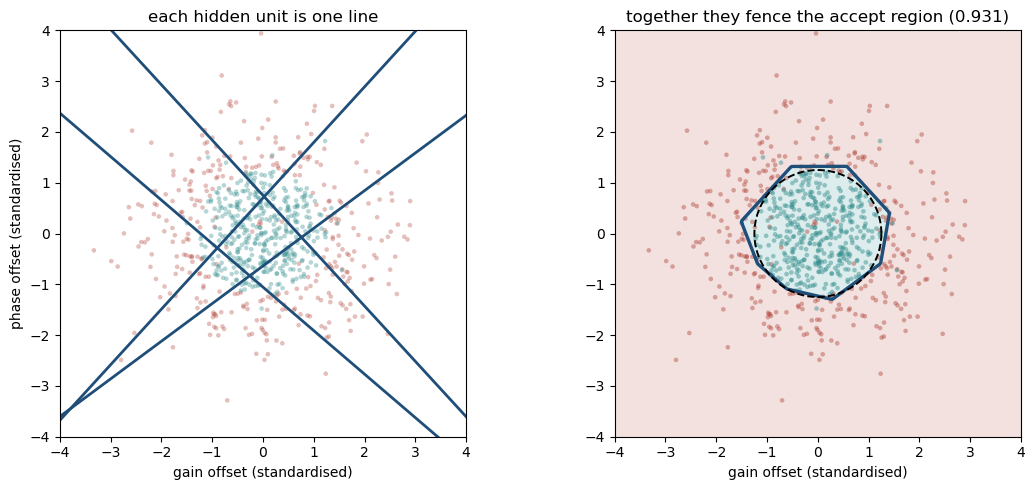

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 5.0))
W1, b1, W2, b2 = four
span = np.linspace(-4, 4, 200)

ax = axes[0]
for label, colour in ((0, RUST), (1, TEAL)):
    m = y_te == label
    ax.scatter(Z_te[m, 0], Z_te[m, 1], s=11, c=colour, alpha=.35,
               edgecolor="none")
for j in range(W1.shape[1]):
    w0, w1 = W1[:, j]
    if abs(w1) > abs(w0):
        ax.plot(span, -(w0 * span + b1[j]) / w1, lw=2.0, color=BLUE)
    else:
        ax.plot(-(w1 * span + b1[j]) / w0, span, lw=2.0, color=BLUE)
ax.set_title("each hidden unit is one line")
ax.set_xlabel("gain offset (standardised)")
ax.set_ylabel("phase offset (standardised)")
ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
ax.set_aspect("equal")

ax = axes[1]
grid = np.linspace(-4, 4, 300)
xx, yy = np.meshgrid(grid, grid)
surface = forward(four, np.c_[xx.ravel(), yy.ravel()])[2].reshape(xx.shape)
ax.contourf(xx, yy, surface, levels=[0, .5, 1], colors=[RUST, TEAL], alpha=.16)
ax.contour(xx, yy, surface, levels=[.5], colors=[BLUE], linewidths=2.4)
for label, colour in ((0, RUST), (1, TEAL)):
    m = y_te == label
    ax.scatter(Z_te[m, 0], Z_te[m, 1], s=11, c=colour, alpha=.45,
               edgecolor="none")
theta = np.linspace(0, 2 * np.pi, 400)
ax.plot(TRUE_ACCEPT_RADIUS_SIGMA * np.cos(theta),
        TRUE_ACCEPT_RADIUS_SIGMA * np.sin(theta), color="k", lw=1.4, ls="--")
ax.set_title(f"together they fence the accept region ({four_acc:.3f})")
ax.set_xlabel("gain offset (standardised)")
ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
ax.set_aspect("equal")

fig.tight_layout()
fig.savefig(FIGURES / "four_lines_fence.png", dpi=150)
plt.show()

## 8. The smallest problem that needs a hidden layer

Meridian's two-channel sensors drift with temperature. When both channels
drift the same way the drift is common mode and one global correction removes
it; when they drift oppositely it is differential and nothing can. So a unit
is correctable exactly when the two drifts share a sign — exclusive-or on the
signs, four clouds in a checkerboard.

In [15]:
drift = make_channel_drift()
D = drift[["drift_a_mv", "drift_b_mv"]].values
d = drift["correctable"].values

print(f"{len(drift)} two-channel units, {d.mean():.2f} correctable")
print(f"logistic regression: {LogisticRegression().fit(D, d).score(D, d):.4f}")

800 two-channel units, 0.50 correctable
logistic regression: 0.5000


Half. A line is worth precisely nothing here.

Two hidden units are enough, and rather than train them, here are weights
chosen by hand — the construction handout section 3 works through. Both clouds
of correctable units have $a + b \approx \pm 2$; both clouds of uncorrectable
ones have $a + b \approx 0$. So the rule is "$|a+b|$ is large", and $|a+b|$ is
exactly what two ReLU units compute between them.

In [16]:
hand_built = [np.array([[1.0, -1.0],       # unit 1:  a + b - 1
                        [1.0, -1.0]]),     # unit 2: -a - b - 1
              np.array([-1.0, -1.0]),
              np.array([[10.0], [10.0]]),
              np.array([-1.0])]

corners = np.array([[1., 1.], [-1., -1.], [1., -1.], [-1., 1.]])
_, corner_hidden, corner_out = forward(hand_built, corners)
for point, hidden, out in zip(corners, corner_hidden, corner_out.ravel()):
    print(f"  a={point[0]:+.0f} b={point[1]:+.0f}  ->  h = {hidden.round(2)}"
          f"  ->  sigmoid = {out:.4f}  ->  class {int(out > 0.5)}")

hand_acc = accuracy(hand_built, D, d)
print(f"\nhand-built network on all {len(drift)} units: {hand_acc:.4f}"
      f"   ({round((1 - hand_acc) * len(drift))} wrong)")

  a=+1 b=+1  ->  h = [1. 0.]  ->  sigmoid = 0.9999  ->  class 1
  a=-1 b=-1  ->  h = [0. 1.]  ->  sigmoid = 0.9999  ->  class 1
  a=+1 b=-1  ->  h = [0. 0.]  ->  sigmoid = 0.2689  ->  class 0
  a=-1 b=+1  ->  h = [0. 0.]  ->  sigmoid = 0.2689  ->  class 0

hand-built network on all 800 units: 0.9938   (5 wrong)


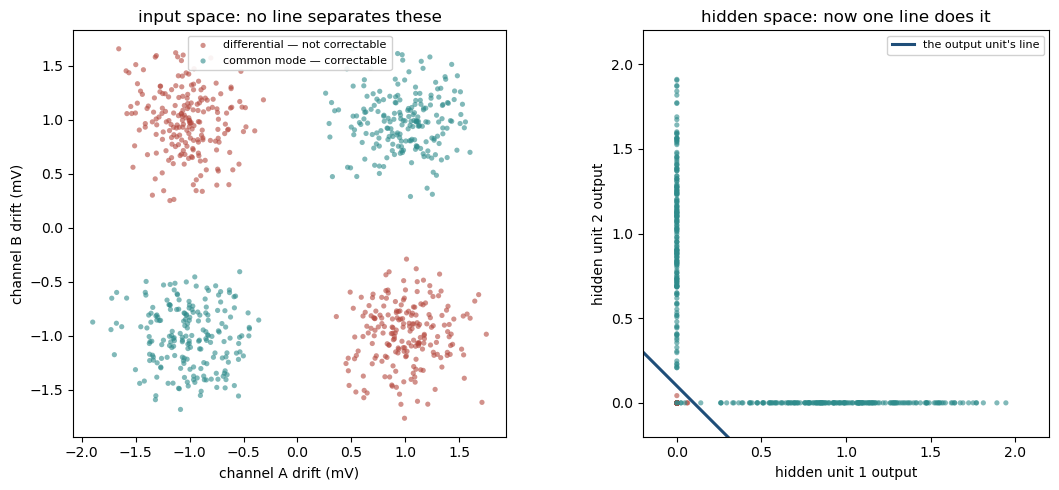

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 5.0))
_, hidden_all, _ = forward(hand_built, D)

ax = axes[0]
for label, colour, name in ((0, RUST, "differential — not correctable"),
                            (1, TEAL, "common mode — correctable")):
    m = d == label
    ax.scatter(D[m, 0], D[m, 1], s=14, c=colour, alpha=.6, edgecolor="none",
               label=name)
ax.set_xlabel("channel A drift (mV)")
ax.set_ylabel("channel B drift (mV)")
ax.set_title("input space: no line separates these")
ax.legend(loc="upper center", fontsize=8, framealpha=.9)
ax.set_aspect("equal")

ax = axes[1]
for label, colour in ((0, RUST), (1, TEAL)):
    m = d == label
    ax.scatter(hidden_all[m, 0], hidden_all[m, 1], s=14, c=colour, alpha=.6,
               edgecolor="none")
edge = np.linspace(-0.2, 2.2, 10)
ax.plot(edge, 0.1 - edge, color=BLUE, lw=2.2, label="the output unit's line")
ax.set_xlabel("hidden unit 1 output")
ax.set_ylabel("hidden unit 2 output")
ax.set_title("hidden space: now one line does it")
ax.legend(loc="upper right", fontsize=8, framealpha=.9)
ax.set_xlim(-0.2, 2.2)
ax.set_ylim(-0.2, 2.2)
ax.set_aspect("equal")

fig.tight_layout()
fig.savefig(FIGURES / "xor_hidden_space.png", dpi=150)
plt.show()

The hidden layer did not classify anything. It **moved the data** — the two
correctable clouds to $(1,0)$ and $(0,1)$, both uncorrectable clouds on top of
each other at the origin — and left a problem the output unit's single line
can solve. That is what "learning a representation" means, and it is the idea
the rest of deep learning is built on.

Now the uncomfortable part. Those weights exist and score above 0.99. How
often does gradient descent *find* them?

In [18]:
rows = []
for n_hidden in (2, 3, 4, 8):
    scores = [accuracy(train(D, d, n_hidden, epochs=400, learning_rate=0.3,
                             seed=s)[0], D, d) for s in range(20)]
    rows.append({"hidden units": n_hidden,
                 "median accuracy": round(float(np.median(scores)), 4),
                 "best of 20": round(max(scores), 4),
                 "runs above 0.95": f"{sum(s > 0.95 for s in scores)}/20"})
print(f"the hand-built 2-unit network scores {hand_acc:.4f}\n")
pd.DataFrame(rows).set_index("hidden units")

the hand-built 2-unit network scores 0.9938



,median accuracy,best of 20,runs above 0.95
hidden units,,,
2,0.75,0.9975,4/20
3,1.00,1.0000,15/20
4,1.00,1.0000,19/20
8,1.00,1.0000,20/20


**Representable and findable are different properties.** Two units suffice —
the weights are printed above — and plain gradient descent lands on them in a
small minority of attempts, because from most random starts the quickest
descent leads instead to a solution that carves off one quadrant and stops at
0.75. Extra units do not add capacity this problem needs; they add *starting
points*, so that some unit begins near a useful line.

This is the honest reason production networks are wider than their task
requires, and it is worth remembering the next time a network "does not work":
the architecture may be fine and the search may simply have failed.

## 9. How many lines does the accept region need?

Back to the sensors. The hidden layer has $H$ units, so it draws $H$ lines. A
useful yardstick: how well could the *best possible* fence of $H$ lines do?

For a disc the natural fence is a regular $H$-sided polygon, and its accuracy
can be computed exactly rather than searched for. In polar coordinates a
regular polygon of apothem $a$ has boundary $r(t) = a/\cos t$ for
$|t| \le \pi/H$, and for a standard two-dimensional normal
$P(r < s) = 1 - e^{-s^2/2}$, so the disagreement with the true circle of
radius $R$ reduces to a one-dimensional integral.

In [19]:
R = TRUE_ACCEPT_RADIUS_SIGMA
reference = np.random.default_rng(20260909).standard_normal((400_000, 2))
reference_inside = (reference ** 2).sum(1) < R * R


def with_rig_error(clean):
    """Accuracy against recorded labels, given accuracy against the truth."""
    return clean * (1 - TRUE_RIG_ERROR_RATE) + (1 - clean) * TRUE_RIG_ERROR_RATE


def polygon_accuracy(n_sides, apothem):
    """Exact accuracy of a regular n-gon against the true circle."""
    def disagreement(t):
        boundary = apothem / np.cos(t)
        lo, hi = min(R, boundary), max(R, boundary)
        return np.exp(-lo * lo / 2) - np.exp(-hi * hi / 2)
    area, _ = integrate.quad(disagreement, -np.pi / n_sides, np.pi / n_sides,
                             limit=200)
    return 1.0 - area * n_sides / (2 * np.pi)


def best_fence(n_lines):
    """Best accuracy attainable with n_lines straight boundaries."""
    if n_lines == 1:                                    # a half-plane
        candidates = [((reference[:, 0] < a) == reference_inside).mean()
                      for a in np.linspace(-0.5, 4.0, 451)]
    elif n_lines == 2:                                  # a strip
        candidates = [((np.abs(reference[:, 0]) < a) == reference_inside).mean()
                      for a in np.linspace(0.2, 3.5, 331)]
    else:
        candidates = [polygon_accuracy(n_lines, a)
                      for a in np.linspace(0.6 * R, 2.2 * R, 401)]
    return with_rig_error(max(candidates))


widths = [1, 2, 3, 4, 6, 8, 16, 32]
fences = {h: best_fence(h) for h in widths}
for h in widths:
    print(f"  {h:2d} lines: best fence {fences[h]:.4f}")
print(f"  the true circle       : {with_rig_error(1.0):.4f}")

   1 lines: best fence 0.6491
   2 lines: best fence 0.7593
   3 lines: best fence 0.8632
   4 lines: best fence 0.9132
   6 lines: best fence 0.9460
   8 lines: best fence 0.9567
  16 lines: best fence 0.9667
  32 lines: best fence 0.9689
  the true circle       : 0.9700


A second route on the same quantity, because an integral written out by hand
is exactly the kind of thing that can be quietly wrong: score the same
polygons against a large sample instead.

In [20]:
for n_sides in (4, 8, 16):
    angles = np.arange(n_sides) * 2 * np.pi / n_sides
    directions = np.c_[np.cos(angles), np.sin(angles)]
    apothems = np.linspace(0.6 * R, 2.2 * R, 401)
    reach = (reference @ directions.T).max(1)
    sampled = max(((reach < a) == reference_inside).mean() for a in apothems)
    exact = max(polygon_accuracy(n_sides, a) for a in apothems)
    print(f"  {n_sides:2d}-gon: integral {exact:.4f}   sample {sampled:.4f}"
          f"   difference {abs(exact - sampled):.4f}")

   4-gon: integral 0.9396   sample 0.9392   difference 0.0004
   8-gon: integral 0.9859   sample 0.9858   difference 0.0000
  16-gon: integral 0.9965   sample 0.9965   difference 0.0000


In [21]:
REPEATS, RESTARTS = 5, 5
sweep = []
for n_hidden in widths:
    fitted = [min([train(Z_tr, y_tr, n_hidden, seed=300 + block * 10 + r)
                   for r in range(RESTARTS)],
                  key=lambda run: run[1][-1])[0]
              for block in range(REPEATS)]
    recorded = [accuracy(p, Z_te, y_te) for p in fitted]
    against_truth = [accuracy(p, Z_te, t_te) for p in fitted]
    sweep.append({"hidden units": n_hidden,
                  "trained (mean)": np.mean(recorded),
                  "sd": np.std(recorded),
                  "best fence of H lines": fences[n_hidden],
                  "vs the true rule": np.mean(against_truth)})
sweep = pd.DataFrame(sweep).set_index("hidden units")
sweep.round(4)

,trained (mean),sd,best fence of H lines,vs the true rule
hidden units,,,,
1,0.6512,0.0106,0.6491,0.6621
2,0.7392,0.0016,0.7593,0.7592
3,0.9421,0.0037,0.8632,0.9685
4,0.9379,0.0101,0.9132,0.9664
6,0.9411,0.0039,0.9460,0.9696
8,0.9421,0.0068,0.9567,0.9717
16,0.9475,0.0074,0.9667,0.9760
32,0.9469,0.0047,0.9689,0.9776


Before reading the table, one check that ties its two accuracy columns
together. If a network agrees with the *true* rule on a fraction $q$ of units,
and the rig records the wrong verdict independently with probability
$e = 0.03$, the two disagree in exactly the cases where one of them is wrong:

$$\text{accuracy against recorded labels} = q(1 - e) + (1 - q)e$$

If that identity holds across the whole sweep, the two columns are measuring
what they claim to.

In [22]:
predicted = (sweep["vs the true rule"] * (1 - TRUE_RIG_ERROR_RATE)
             + (1 - sweep["vs the true rule"]) * TRUE_RIG_ERROR_RATE)
comparison = pd.DataFrame({"observed": sweep["trained (mean)"],
                           "predicted from the truth column": predicted,
                           "difference": sweep["trained (mean)"] - predicted})
print(f"largest discrepancy: {comparison['difference'].abs().max():.4f}")
comparison.round(4)

largest discrepancy: 0.0044


,observed,predicted from the truth column,difference
hidden units,,,
1,0.6512,0.6524,-0.0012
2,0.7392,0.7436,-0.0044
3,0.9421,0.9404,0.0017
4,0.9379,0.9384,-0.0005
6,0.9411,0.9414,-0.0004
8,0.9421,0.9434,-0.0013
16,0.9475,0.9474,0.0000
32,0.9469,0.9489,-0.0020


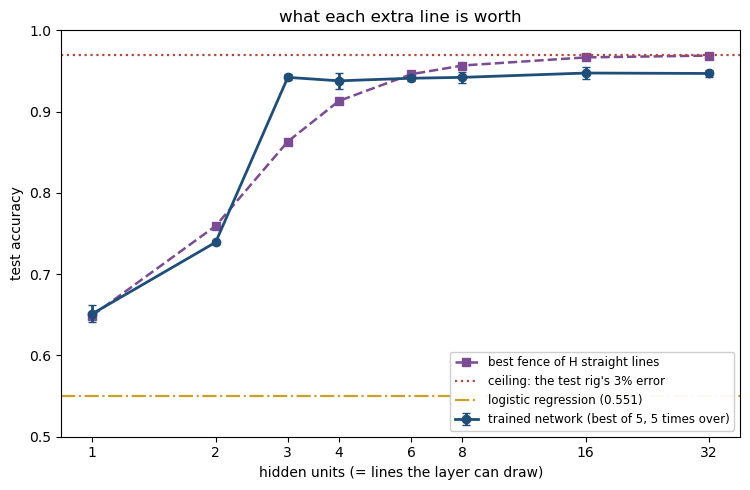

In [23]:
fig, ax = plt.subplots(figsize=(7.6, 5.0))
ax.plot(sweep.index, sweep["best fence of H lines"], "s--", color=PLUM, lw=1.8,
        ms=6, label="best fence of H straight lines")
ax.errorbar(sweep.index, sweep["trained (mean)"], yerr=sweep["sd"], fmt="o-",
            color=BLUE, lw=2.0, ms=6, capsize=3,
            label=f"trained network (best of {RESTARTS}, {REPEATS} times over)")
ax.axhline(1 - TRUE_RIG_ERROR_RATE, color=RUST, lw=1.6, ls=":",
           label="ceiling: the test rig's 3% error")
ax.axhline(linear_acc, color=GOLD, lw=1.6, ls="-.",
           label=f"logistic regression ({linear_acc:.3f})")
ax.set_xscale("log", base=2)
ax.set_xticks(widths)
ax.set_xticklabels(widths)
ax.set_xlabel("hidden units (= lines the layer can draw)")
ax.set_ylabel("test accuracy")
ax.set_title("what each extra line is worth")
ax.legend(loc="lower right", fontsize=8.5, framealpha=.95)
ax.set_ylim(0.5, 1.0)
fig.tight_layout()
fig.savefig(FIGURES / "width_sweep.png", dpi=150)
plt.show()

Four things to read off this, in order of how much they matter.

**Almost all of the gain arrives in the first three lines.** One unit scores
about the same as the best single line. Three is enough to enclose a region,
and from there the curve is essentially flat: everything between three units
and thirty-two is worth less than the step from two units to three.

**The polygon is a floor, not a ceiling.** At three and four units the trained
network beats the best regular polygon of the same number of sides, and by a
wide margin at three. Three lines cut the plane into seven regions, not one
triangle, and the output unit's weighted vote can select a shape those lines
bound in more ways than "inside all of them". So the fence curve says what $H$
lines are *at least* worth, and the network does better.

**Past six units the constraint changes.** The fence curve keeps climbing
towards 0.97 as more sides become available, and the trained network does not
follow it: it settles just below 0.95. Extra lines are there and gradient
descent does not put them to work. That gap is the optimiser, not the
architecture, and notebook 03 comes back to it.

**The visible ceiling is not the real one.** The last column scores the same
networks against `truly_within_tolerance` rather than the recorded verdict,
and runs about three points higher — the network has learned the true
boundary considerably better than its measured score suggests. The gap is the
test rig, and on a real dataset only the first column would exist.

## 10. The one initialisation that cannot work

Lesson 3 started gradient descent from $w = 0$, and that was the right choice:
for linear and logistic regression the cost is convex and zero is as good a
starting point as any. Carrying that habit into a network breaks it
completely, and the reason is worth seeing rather than being told.

In [24]:
zeros = [np.zeros((2, 32)), np.zeros(32), np.zeros((32, 1)), np.zeros(1)]
zero_params, zero_history = train(Z_tr, y_tr, 32, seed=1, params=zeros)
random_params, random_history = train(Z_tr, y_tr, 32, seed=1)

print(f"zero init  : test accuracy {accuracy(zero_params, Z_te, y_te):.4f}"
      f"   final cost {zero_history[-1]:.4f}")
print(f"random init: test accuracy {accuracy(random_params, Z_te, y_te):.4f}"
      f"   final cost {random_history[-1]:.4f}")
print(f"\ndistinct hidden units after training from zero  : "
      f"{np.unique(zero_params[0].round(10), axis=1).shape[1]} of 32")
print(f"distinct hidden units after training from random: "
      f"{np.unique(random_params[0].round(10), axis=1).shape[1]} of 32")

zero init  : test accuracy 0.5480   final cost 0.6887
random init: test accuracy 0.9173   final cost 0.2486

distinct hidden units after training from zero  : 1 of 32
distinct hidden units after training from random: 32 of 32


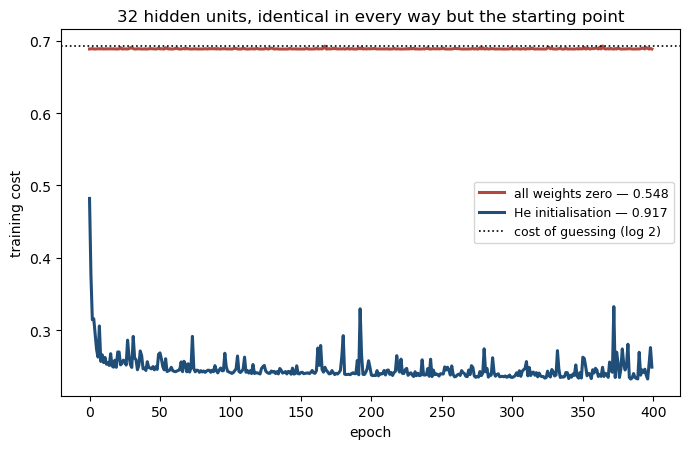

In [25]:
fig, ax = plt.subplots(figsize=(7.0, 4.6))
ax.plot(zero_history, color=RUST, lw=2.2,
        label=f"all weights zero — {accuracy(zero_params, Z_te, y_te):.3f}")
ax.plot(random_history, color=BLUE, lw=2.2,
        label=f"He initialisation — {accuracy(random_params, Z_te, y_te):.3f}")
ax.axhline(np.log(2), color="k", lw=1.2, ls=":", label="cost of guessing (log 2)")
ax.set_xlabel("epoch")
ax.set_ylabel("training cost")
ax.set_title("32 hidden units, identical in every way but the starting point")
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(FIGURES / "zero_init_symmetry.png", dpi=150)
plt.show()

All 32 units collapse to **one**. If every unit starts with identical weights
then every unit computes the same thing, so every unit receives the same
gradient, so every unit takes the same step — for ever. The layer has 32 units
and one degree of freedom, and no amount of training breaks the tie, because
nothing in the update rule distinguishes one unit from another.

Random initialisation is not a heuristic that happens to help. It is what
makes the units *different problems to solve*, and handout section 8 derives
how large those random values should be.

## Summary

- One neuron is one line. On a problem whose answer is "inside a region",
  logistic regression scores essentially the majority-class rate, and the best
  line anywhere does only a little better.
- A hidden layer of $H$ ReLU units draws $H$ lines and votes over them. Three
  or four are enough to fence a disc, and further units add very little.
- Backpropagation is the chain rule applied right to left, reusing what the
  forward pass already computed. The sigmoid and cross-entropy pair collapses
  to $\hat{y} - y$.
- **Check the gradient against finite differences.** It costs four lines, and
  it is the only thing standing between you and a wrong gradient that trains
  anyway.
- A hidden layer does not classify — it moves the data until the last layer's
  single line is enough.
- Capacity is necessary, not sufficient: the two-unit solution to the drift
  problem exists, and gradient descent rarely finds it.
- Never initialise a network's weights to zero: identical units stay identical
  for ever.

Notebook 02 moves to Keras, to more than two classes, and to what goes wrong
when the network gets deep.